In [20]:
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.fx.experimental.proxy_tensor import make_fx
import matplotlib.pyplot as plt

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


**Part 1: Comparing Backends**

In [3]:
class SimpleNet(nn.Module):
    def __init__(self, in_dim=1024, hidden=2048, out_dim=512):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, hidden)
        self.fc2 = nn.Linear(hidden, hidden)
        self.fc3 = nn.Linear(hidden, out_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [4]:
def benchmark_model(model, backend_name, x, target, steps=100):
    if backend_name == "eager":
        compiled = model
    else:
        compiled = torch.compile(model, backend=backend_name)

    criterion = nn.MSELoss()
    optimizer = torch.optim.SGD(compiled.parameters(), lr=1e-3)

    for _ in range(10):
        optimizer.zero_grad()
        out = compiled(x)
        loss = criterion(out, target)
        loss.backward()
        optimizer.step()

    if device == "cuda":
        torch.cuda.synchronize()

    start = time.perf_counter()
    for _ in range(steps):
        optimizer.zero_grad()
        out = compiled(x)
        loss = criterion(out, target)
        loss.backward()
        optimizer.step()
    if device == "cuda":
        torch.cuda.synchronize()
    end = time.perf_counter()

    return (end - start) / steps

In [5]:
backends = ["eager", "aot_eager", "inductor", "cudagraphs"]

x = torch.randn(256, 1024, device=device)
target = torch.randn(256, 512, device=device)

results = {}

for backend in backends:
    try:
        model = SimpleNet().to(device)
        avg_time = benchmark_model(model, backend, x, target, steps=100)
        results[backend] = avg_time
        print(f"{backend}: {avg_time:.6f}s")
    except Exception as e:
        results[backend] = None
        print(f"{backend} failed: {e}")

eager: 0.003670s
aot_eager: 0.003432s


W0316 09:30:53.340000 4365 torch/_inductor/utils.py:1679] [0/1] Not enough SMs to use max_autotune_gemm mode


inductor: 0.003244s
cudagraphs: 0.003112s


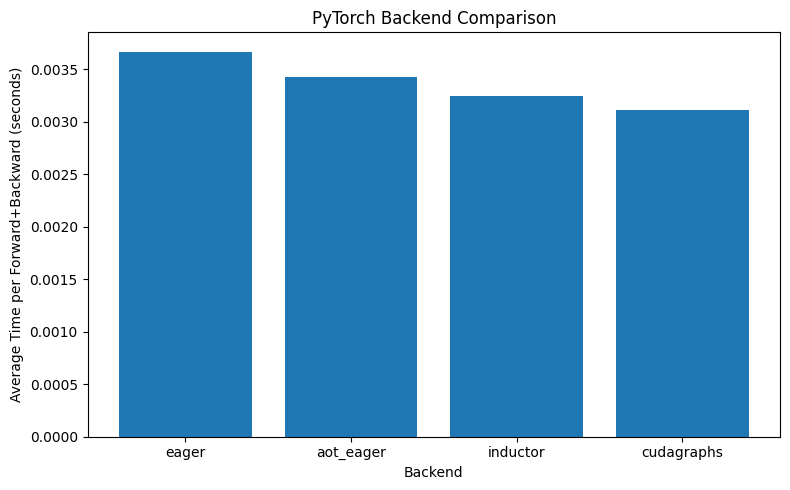

In [6]:
valid = {k: v for k, v in results.items() if v is not None}

plt.figure(figsize=(8, 5))
plt.bar(list(valid.keys()), list(valid.values()))
plt.xlabel("Backend")
plt.ylabel("Average Time per Forward+Backward (seconds)")
plt.title("PyTorch Backend Comparison")
plt.tight_layout()
plt.show()

**Part 2: Debugging Compilation Failures**

In [7]:
def problem1(x):
    if x.sum() > 0:
        return x * 2
    else:
        return x / 2

def problem2(x):
    d = {}
    d["key"] = x
    return d["key"] * 2

def problem3(x):
    result = 0
    for i in range(10):
        result += (x ** i).sum()
    return result

In [8]:
sample = torch.randn(512, 512, device=device)

for fn in [problem1, problem2, problem3]:
    print("=" * 80)
    print("Function:", fn.__name__)
    try:
        compiled_fn = torch.compile(fn)
        y = compiled_fn(sample)
        if isinstance(y, torch.Tensor) and device == "cuda":
            torch.cuda.synchronize()
        print("Compiled successfully.")
    except Exception as e:
        print("Compilation issue:", e)

    try:
        explanation = torch._dynamo.explain(fn)(sample)
        print(explanation)
    except Exception as e:
        print("Explain failed:", e)

Function: problem1
Compiled successfully.
Graph Count: 2
Graph Break Count: 1
Op Count: 2
Break Reasons:
  Break Reason 1:
    Reason: generic_jump TensorVariable()
    User Stack:
      <FrameSummary file /tmp/ipykernel_4365/1682608975.py, line 2 in problem1>
Ops per Graph:
  Ops 1:
    <built-in function gt>
  Ops 2:
    <built-in function truediv>
Out Guards:
  Guard 1:
    Name: ''
    Source: shape_env
    Create Function: SHAPE_ENV
    Guard Types: None
    Code List: None
    Object Weakref: None
    Guarded Class Weakref: None
  Guard 2:
    Name: ''
    Source: global
    Create Function: DETERMINISTIC_ALGORITHMS
    Guard Types: None
    Code List: None
    Object Weakref: None
    Guarded Class Weakref: None
  Guard 3:
    Name: ''
    Source: global
    Create Function: GRAD_MODE
    Guard Types: None
    Code List: None
    Object Weakref: None
    Guarded Class Weakref: None
  Guard 4:
    Name: ''
    Source: global
    Create Function: DEFAULT_DEVICE
    Guard Types: ['

Fixed Versions:

In [9]:
def problem1_fixed(x):
    cond = (x.sum() > 0)
    return torch.where(cond, x * 2, x / 2)

def problem2_fixed(x):
    return x * 2

def problem3_fixed(x):
    powers = torch.arange(10, device=x.device)
    expanded = x.unsqueeze(0) ** powers.view(-1, 1, 1)
    return expanded.sum()

In [10]:
for fn in [problem1_fixed, problem2_fixed, problem3_fixed]:
    print("=" * 80)
    print("Fixed function:", fn.__name__)
    compiled_fn = torch.compile(fn)
    y = compiled_fn(sample)
    if isinstance(y, torch.Tensor) and device == "cuda":
        torch.cuda.synchronize()
    print("Compiled successfully.")

Fixed function: problem1_fixed
Compiled successfully.
Fixed function: problem2_fixed
Compiled successfully.
Fixed function: problem3_fixed
Compiled successfully.


**Part 3: Graph Capture and Inspection**

In [24]:
side_effect_log = []

def graph_capture_demo(x, w1, w2):
    y = x @ w1
    y = y @ w2
    y = F.relu(y)
    y = y + x
    y = F.layer_norm(y, normalized_shape=(y.shape[-1],))
    print('Hello')
    side_effect_log.append(1)
    return y

def pure_tensor_part(x, w1, w2):
    y = x @ w1
    y = y @ w2
    y = F.relu(y)
    y = y + x
    y = F.layer_norm(y, normalized_shape=(y.shape[-1],))
    return y

In [25]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

x = torch.randn(4, 8, device=device)
w1 = torch.randn(8, 8, device=device)
w2 = torch.randn(8, 8, device=device)

side_effect_log.clear()
out_eager = graph_capture_demo(x, w1, w2)
print('Output shape:', out_eager.shape)
print('List after eager run:', side_effect_log)

Hello
Output shape: torch.Size([4, 8])
List after eager run: [1]


In [26]:
side_effect_log.clear()

try:
    compiled_fn = torch.compile(graph_capture_demo, fullgraph=True)
    out_compiled = compiled_fn(x, w1, w2)
    print('Compiled output shape:', out_compiled.shape)
    print('List after compiled run:', side_effect_log)
except Exception as e:
    print('Compilation failed under fullgraph=True')
    print('Exception type:', type(e).__name__)
    print('Message:', e)

Compilation failed under fullgraph=True
Exception type: Unsupported
Message: Failed to trace builtin operator
  Explanation: Dynamo does not know how to trace builtin operator `print` with argument types ['str'] (has_kwargs False)
  Hint: Avoid calling builtin `print` with argument types ['str']. Consider using an equivalent alternative function/method to `print`.
  Hint: If you are attempting to call a logging function (e.g. `print`), you can try adding it to `torch._dynamo.config.reorderable_logging_functions`.
  Hint: Please report an issue to PyTorch.

  Developer debug context: builtin print [<class 'torch._dynamo.variables.constant.ConstantVariable'>] False

 For more details about this graph break, please visit: https://meta-pytorch.github.io/compile-graph-break-site/gb/gb0059.html

from user code:
   File "/tmp/ipykernel_4365/3779024060.py", line 9, in graph_capture_demo
    print('Hello')

Set TORCHDYNAMO_VERBOSE=1 for the internal stack trace (please do this especially if you

In [27]:
side_effect_log.clear()

try:
    explanation = torch._dynamo.explain(graph_capture_demo)(x, w1, w2)
    print(explanation)
except Exception as e:
    print('Explain failed')
    print('Exception type:', type(e).__name__)
    print('Message:', e)


Hello
Graph Count: 1
Graph Break Count: 0
Op Count: 5
Break Reasons:
  Break Reason 1:
    Reason: Failed to trace builtin operator
  Explanation: Dynamo does not know how to trace builtin operator `print` with argument types ['str'] (has_kwargs False)
  Hint: Avoid calling builtin `print` with argument types ['str']. Consider using an equivalent alternative function/method to `print`.
  Hint: If you are attempting to call a logging function (e.g. `print`), you can try adding it to `torch._dynamo.config.reorderable_logging_functions`.
  Hint: Please report an issue to PyTorch.

  Developer debug context: builtin print [<class 'torch._dynamo.variables.constant.ConstantVariable'>] False

 For more details about this graph break, please visit: https://meta-pytorch.github.io/compile-graph-break-site/gb/gb0059.html
    User Stack:
      <FrameSummary file /tmp/ipykernel_4365/3779024060.py, line 9 in graph_capture_demo>
Ops per Graph:
  Ops 1:
    <built-in function matmul>
    <built-in fun

In [28]:
fx_graph = make_fx(pure_tensor_part)(x, w1, w2)
print('=== FX Graph ===')
print(fx_graph.graph)

print('\n=== Generated FX Code ===')
print(fx_graph.code)

=== FX Graph ===
graph():
    %x_1 : [num_users=2] = placeholder[target=x_1]
    %w1_1 : [num_users=1] = placeholder[target=w1_1]
    %w2_1 : [num_users=1] = placeholder[target=w2_1]
    %mm : [num_users=1] = call_function[target=torch.ops.aten.mm.default](args = (%x_1, %w1_1), kwargs = {})
    %mm_1 : [num_users=1] = call_function[target=torch.ops.aten.mm.default](args = (%mm, %w2_1), kwargs = {})
    %relu : [num_users=1] = call_function[target=torch.ops.aten.relu.default](args = (%mm_1,), kwargs = {})
    %add : [num_users=1] = call_function[target=torch.ops.aten.add.Tensor](args = (%relu, %x_1), kwargs = {})
    %native_layer_norm : [num_users=3] = call_function[target=torch.ops.aten.native_layer_norm.default](args = (%add, [8], None, None, 1e-05), kwargs = {})
    %getitem : [num_users=1] = call_function[target=operator.getitem](args = (%native_layer_norm, 0), kwargs = {})
    %getitem_1 : [num_users=0] = call_function[target=operator.getitem](args = (%native_layer_norm, 1), kwarg

Saved graph to: torch_compile_graph.png


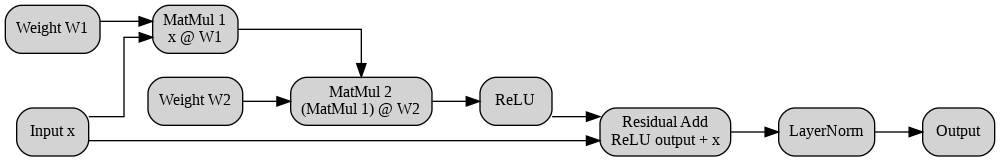

In [29]:
from graphviz import Digraph
from IPython.display import Image, display

def draw_clean_computation_graph(save_name="torch_compile_graph"):
    dot = Digraph(name="ComputationGraph", format="png")
    dot.attr(rankdir="LR", splines="ortho")
    dot.attr("node", shape="box", style="rounded,filled", fontsize="12")

    # Human-readable nodes
    dot.node("x", "Input x")
    dot.node("w1", "Weight W1")
    dot.node("w2", "Weight W2")
    dot.node("mm1", "MatMul 1\nx @ W1")
    dot.node("mm2", "MatMul 2\n(MatMul 1) @ W2")
    dot.node("relu", "ReLU")
    dot.node("add", "Residual Add\nReLU output + x")
    dot.node("ln", "LayerNorm")
    dot.node("out", "Output")

    # Edges
    dot.edge("x", "mm1")
    dot.edge("w1", "mm1")
    dot.edge("mm1", "mm2")
    dot.edge("w2", "mm2")
    dot.edge("mm2", "relu")
    dot.edge("relu", "add")
    dot.edge("x", "add")
    dot.edge("add", "ln")
    dot.edge("ln", "out")

    # Save to file
    output_path = dot.render(filename=save_name, cleanup=True)
    print("Saved graph to:", output_path)

    # Show image in notebook
    display(Image(filename=output_path))

draw_clean_computation_graph()